<a href="https://colab.research.google.com/github/taru30174/my-_projects/blob/main/AI_Personal_Finance_Behavior_Analyzer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


Feature sample:
         income     spending      savings  spending_ratio  risk
user_id                                                        
0        3860.0  1548.413834  2311.586166        0.401143     0
1        4527.0  1827.063215  2699.936785        0.403592     0
2        9313.0  3718.158111  5594.841889        0.399244     0
3        9891.0  3946.357118  5944.642882        0.398985     0
4        4823.0  1937.593736  2885.406264        0.401740     0

User clusters:
cluster
1    98
0    55
2    47
Name: count, dtype: int64

Risk prediction report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        40

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


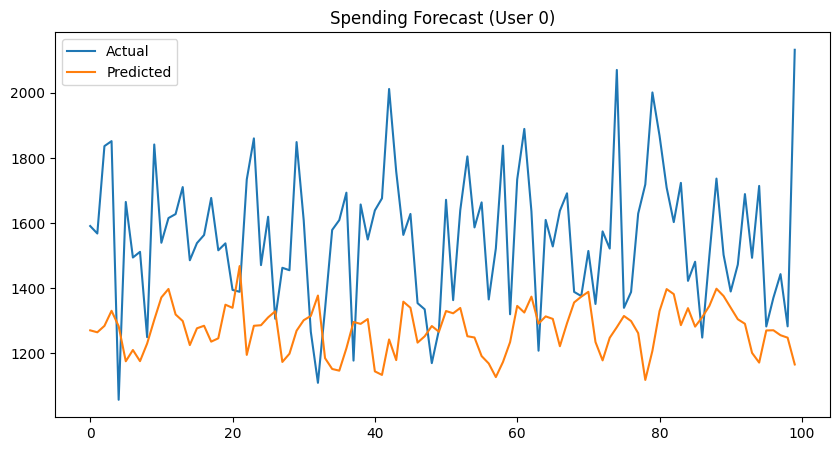

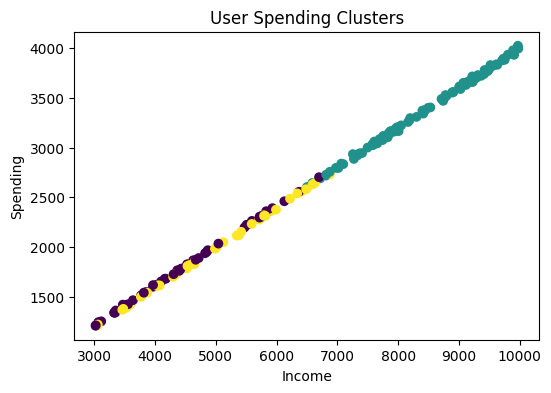

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input

# 1. Generate Synthetic Transaction Data


np.random.seed(42)
users = 200
days = 180
data = []
for user in range(users):
    base_income = np.random.randint(3000, 10000)
    for day in range(days):
        spending = np.random.normal(base_income * 0.4, 200)
        savings = base_income - spending
        data.append([user,day,base_income,max(spending, 0),max(savings, 0)])
df = pd.DataFrame(data, columns=["user_id", "day", "income", "spending", "savings"])

# 2. Feature Engineering


features = df.groupby("user_id").agg({ "income": "mean","spending": "mean", "savings": "mean"})
features["spending_ratio"] = features["spending"] / features["income"]

# Risk label (overspending users)

features["risk"] = (features["spending_ratio"] > 0.6).astype(int)
print("\nFeature sample:")
print(features.head())

# 3. Clustering (Behavior Segmentation)

X_cluster = features[["income", "spending", "savings", "spending_ratio"]]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)
kmeans = KMeans(n_clusters=3, random_state=42)
features["cluster"] = kmeans.fit_predict(X_scaled)
print("\nUser clusters:")
print(features["cluster"].value_counts())

# 4. Risk Prediction Model (ML)

X = features[["income", "spending", "savings", "spending_ratio"]]
y = features["risk"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
clf = RandomForestClassifier()
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
print("\nRisk prediction report:")
print(classification_report(y_test, y_pred))

# 5. Deep Learning Forecast (LSTM)

user0 = df[df["user_id"] == 0]["spending"].values
sequence_length = 10
X_seq = []
y_seq = []
for i in range(len(user0) - sequence_length):
    X_seq.append(user0[i:i+sequence_length])
    y_seq.append(user0[i+sequence_length])

X_seq = np.array(X_seq)
y_seq = np.array(y_seq)

X_seq = X_seq.reshape((X_seq.shape[0], X_seq.shape[1], 1))
model = Sequential([
    Input(shape=(sequence_length, 1)),
    LSTM(50, activation="relu"),
    Dense(1)])
model.compile(optimizer="adam", loss="mse")
model.fit(X_seq, y_seq, epochs=10, verbose=0)
pred = model.predict(X_seq)

# 6. Visualization Dashboard

plt.figure(figsize=(10, 5))
plt.plot(y_seq[:100], label="Actual")
plt.plot(pred[:100], label="Predicted")
plt.title("Spending Forecast (User 0)")
plt.legend()
plt.show()

plt.figure(figsize=(6, 4))
plt.scatter(features["income"], features["spending"],
            c=features["cluster"])
plt.xlabel("Income")
plt.ylabel("Spending")
plt.title("User Spending Clusters")
plt.show()